In [105]:
# Importing Libraries
import os
import kagglehub
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from xgboost import XGBClassifier

import joblib

In [106]:
# =========================
# Step 2: Download Dataset
# =========================
path = kagglehub.dataset_download("algozee/credit-risk-and-loan-default-analysis-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in dataset folder:")
for f in files:
    print(f)


Path to dataset files: C:\Users\Aditya\.cache\kagglehub\datasets\algozee\credit-risk-and-loan-default-analysis-dataset\versions\1
Files in dataset folder:
loan_risk_prediction_dataset.csv


In [107]:
# =========================
# Step 4: Load Dataset
# =========================
# Replace this with your actual CSV filename after checking Cell 3
csv_file = [f for f in files if f.endswith(".csv")][0]

file_path = os.path.join(path, csv_file)
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


Dataset loaded successfully!
    Age   Income  LoanAmount  ...           City  EmploymentType LoanApproved
0  56.0  48353.0     31258.0  ...        Houston      Unemployed            0
1  69.0  57462.0     23262.0  ...  San Francisco   Self-Employed            0
2  46.0  44219.0     26530.0  ...        Houston   Self-Employed            1
3  32.0  56307.0     11531.0  ...       New York      Unemployed            0
4  60.0  37034.0     27871.0  ...        Chicago      Unemployed            0

[5 rows x 10 columns]


In [108]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [109]:
df.sample(6)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
3832,40,22949.0,6243.0,478.0,26,Male,Masters,Chicago,Salaried,0
2838,67,43986.0,17823.0,672.0,5,Male,High School,Chicago,Unemployed,0
3373,56,50771.0,24087.0,729.0,13,Male,High School,New York,Salaried,1
4775,57,60305.0,18943.0,770.0,26,Female,PhD,Houston,Salaried,1
2213,23,79224.0,18240.0,509.0,18,Male,Masters,Houston,Unemployed,0
3801,35,61850.0,23238.0,586.0,7,Female,High School,San Francisco,Self-Employed,0


In [110]:
# =========================
# Step 5: Explore Dataset
# =========================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of dataset: (5000, 10)

Columns:
 ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
None

Missing Values:
Age                  0
Income             196
LoanAmount           0
CreditSc

In [ ]:
from sklearn.impute import IterativeImputer, SimpleImputer

In [ ]:
# Separate num. and cat. columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'LoanApproved']
Categorical Columns: ['Gender', 'Education', 'City', 'EmploymentType']


In [113]:
target_col = "LoanApproved"

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

if target_col in categorical_cols:
    categorical_cols.remove(target_col)

In [ ]:
# Iterative Imputer for num. columns
iter_imputer = IterativeImputer(random_state=42)

df[numeric_cols] = iter_imputer.fit_transform(df[numeric_cols])

In [ ]:
# Simple Imputer for cat. columns
cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [116]:
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [ ]:
# Encoding Target Variable
print("Unique values in target before encoding:", df[target_col].unique())

if df[target_col].dtype == "object":
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col])

print("Unique values in target after encoding:", df[target_col].unique())

Unique values in target before encoding: [0 1]
Unique values in target after encoding: [0 1]


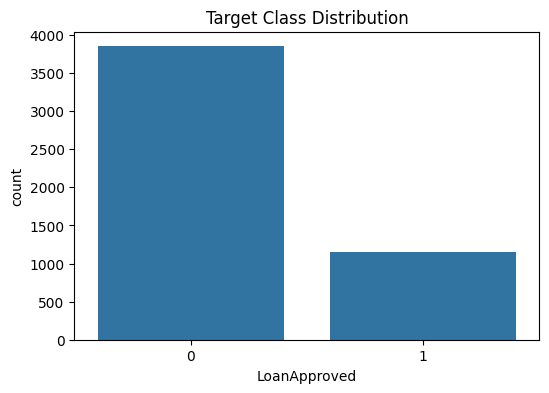

LoanApproved
0    3849
1    1151
Name: count, dtype: int64


In [ ]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title("Target Class Distribution")
plt.show()

print(df[target_col].value_counts())

In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 9)
Target shape: (5000,)


In [ ]:
# One-Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (5000, 14)


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender_Male,Education_High School,Education_Masters,Education_PhD,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56.0,48353.0,31258.0,675.0,20.0,False,True,False,False,True,False,False,False,True
1,69.0,57462.0,23262.0,586.0,6.0,True,True,False,False,False,False,True,True,False
2,46.0,44219.0,26530.0,781.0,26.0,True,False,False,True,True,False,False,True,False
3,32.0,56307.0,11531.0,549.0,11.0,True,False,False,False,False,True,False,False,True
4,60.0,37034.0,27871.0,500.0,19.0,False,True,False,False,False,False,False,False,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (4000, 14)
X_test : (1000, 14)


In [ ]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train XGBoost Model
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)
print("Model training completed!")

Model training completed!


In [ ]:
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(roc_auc, 4))

Accuracy : 0.96
Precision: 0.9524
Recall   : 0.8696
F1 Score : 0.9091
ROC AUC  : 0.9303


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       770
           1       0.95      0.87      0.91       230

    accuracy                           0.96      1000
   macro avg       0.96      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



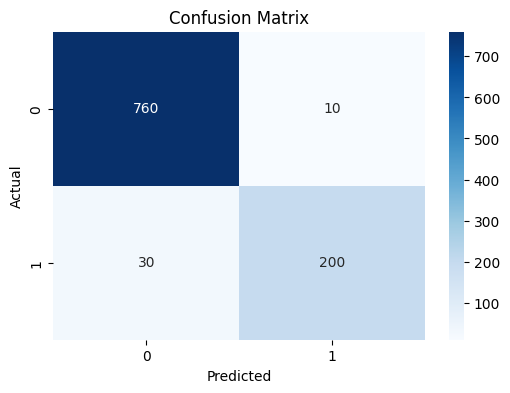

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

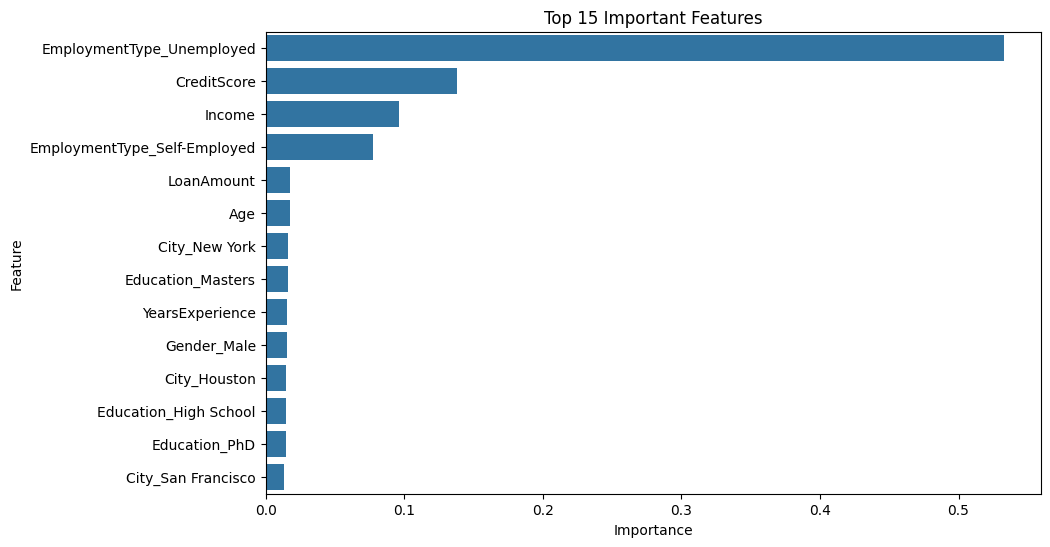

,Feature,Importance
13,EmploymentType_Unemployed,0.532653
3,CreditScore,0.138024
1,Income,0.095998
12,EmploymentType_Self-Employed,0.077618
2,LoanAmount,0.017569
0,Age,0.017321
10,City_New York,0.016068
7,Education_Masters,0.016014
4,YearsExperience,0.015728
5,Gender_Male,0.015356


In [ ]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Important Features")
plt.show()

importance_df.head(15)

In [ ]:
# Save Model & Objects
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Saved files:")
print("- model.pkl")
print("- scaler.pkl")
print("- feature_columns.pkl")

Saved files:
- model.pkl
- scaler.pkl
- feature_columns.pkl
